In [1]:
import polars as pl
from aeon.classification.convolution_based import MiniRocketClassifier, RocketClassifier
from aeon.classification.feature_based import (
    Catch22Classifier,
)
from aeon.datasets.tsc_datasets import univariate_equal_length
from sklearn.metrics import accuracy_score

from autotsc.models import AutoTSCModel
from autotsc.utils import load_dataset

2025-11-16 11:36:59.329989: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [ ]:
stats = []
selected_datasets = univariate_equal_length  # [::3]

In [3]:
import ray

ray.shutdown()
ray.init(num_cpus=24)

2025-11-16 11:37:04,146	INFO worker.py:2012 -- Started a local Ray instance.
/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/ray/_private/worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


Python version:,3.12.0
Ray version:,2.51.1


In [4]:
def get_model(name):
    if name == "Catch22Classifier":
        return Catch22Classifier(n_jobs=-1)
    elif name == "RocketClassifier":
        return RocketClassifier(n_jobs=-1)
    elif name == "MiniRocketClassifier":
        return MiniRocketClassifier(n_jobs=-1)
    elif name == "AutoTSCModel":
        return AutoTSCModel(n_jobs=-1, model_types="catch22", verbose=True)
    else:
        raise ValueError(f"Unknown model name: {name}")


for dataset in selected_datasets:
    X_train, y_train, X_test, y_test = load_dataset(dataset)

    for model_name in [
        "Catch22Classifier",
        "RocketClassifier",
        "MiniRocketClassifier",
        "AutoTSCModel",
    ]:
        try:
            model = get_model(model_name)
            model.fit(X_train, y_train)
            pred = model.predict(X_test)
            test_acc = accuracy_score(y_test, pred)
            stats.append(
                {
                    "dataset": dataset,
                    "model": model_name,
                    "test_accuracy": test_acc,
                }
            )
        except Exception as e:
            print(f"Error with dataset {dataset}: {e}")

|------------------------|
| Number of samples: 100 |
| Number of channels: 1  |
| Length of series: 1460 |
| Number of classes: 10  |
| CPUs: 24/24            |
| GPUs: 2/2              |
|------------------------|
Model 0 fitted, accuracy: 0.6600, time: 0.58s
Error with dataset Beef: n_splits=8 cannot be greater than the number of members in each class.
|-----------------------|
| Number of samples: 30 |
| Number of channels: 1 |
| Length of series: 128 |
| Number of classes: 3  |
| CPUs: 24/24           |
| GPUs: 2/2             |
|-----------------------|
Model 0 fitted, accuracy: 0.8667, time: 0.16s
|-----------------------|
| Number of samples: 20 |
| Number of channels: 1 |
| Length of series: 24  |
| Number of classes: 2  |
| CPUs: 24/24           |
| GPUs: 2/2             |
|-----------------------|
Model 0 fitted, accuracy: 0.9000, time: 0.16s
|-----------------------|
| Number of samples: 28 |
| Number of channels: 1 |
| Length of series: 286 |
| Number of classes: 2  |
| CP

/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=8.
  warnings.warn(


|------------------------|
| Number of samples: 500 |
| Number of channels: 1  |
| Length of series: 140  |
| Number of classes: 5   |
| CPUs: 24/24            |
| GPUs: 2/2              |
|------------------------|
Model 0 fitted, accuracy: 0.9460, time: 0.40s


(pid=gcs_server) [2025-11-16 11:37:32,396 E 4030425 4030425] (gcs_server) gcs_server.cc:302: Failed to establish connection to the event+metrics exporter agent. Events and metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
(raylet) [2025-11-16 11:37:34,067 E 4030577 4030577] (raylet) main.cc:975: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
(make_prediction pid=4030676) [2025-11-16 11:37:36,107 E 4030676 4030935] core_worker_process.cc:825: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
[2025-11-16 11:37:36,506 E 4030354 4030660] core_worker_process.cc:825: Failed to establish connection to the metrics exporter agen

|------------------------|
| Number of samples: 362 |
| Number of channels: 1  |
| Length of series: 1250 |
| Number of classes: 12  |
| CPUs: 24/24            |
| GPUs: 2/2              |
|------------------------|
Model 0 fitted, accuracy: 0.7707, time: 0.87s
|------------------------|
| Number of samples: 560 |
| Number of channels: 1  |
| Length of series: 131  |
| Number of classes: 14  |
| CPUs: 24/24            |
| GPUs: 2/2              |
|------------------------|
Model 0 fitted, accuracy: 0.7839, time: 0.47s


/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=8.
  warnings.warn(


|------------------------|
| Number of samples: 450 |
| Number of channels: 1  |
| Length of series: 270  |
| Number of classes: 50  |
| CPUs: 24/24            |
| GPUs: 2/2              |
|------------------------|
Model 0 fitted, accuracy: 0.5822, time: 0.59s
Error with dataset FiftyWords: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (8, 455) + inhomogeneous part.
|-------------------------|
| Number of samples: 3636 |
| Number of channels: 1   |
| Length of series: 500   |
| Number of classes: 2    |
| CPUs: 24/24             |
| GPUs: 2/2               |
|-------------------------|
Model 0 fitted, accuracy: 0.9035, time: 3.68s
|-----------------------|
| Number of samples: 50 |
| Number of channels: 1 |
| Length of series: 150 |
| Number of classes: 2  |
| CPUs: 24/24           |
| GPUs: 2/2             |
|-----------------------|
Model 0 fitted, accuracy: 0.9600, time: 0.17s
|-------------------

/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=8.
  warnings.warn(


|------------------------|
| Number of samples: 267 |
| Number of channels: 1  |
| Length of series: 270  |
| Number of classes: 25  |
| CPUs: 24/24            |
| GPUs: 2/2              |
|------------------------|
Model 0 fitted, accuracy: 0.5693, time: 0.39s
|------------------------|
| Number of samples: 300 |
| Number of channels: 1  |
| Length of series: 426  |
| Number of classes: 2   |
| CPUs: 24/24            |
| GPUs: 2/2              |
|------------------------|
Model 0 fitted, accuracy: 0.7500, time: 0.40s


In [5]:
stats = pl.DataFrame(stats)
stats

dataset,model,test_accuracy
str,str,f64
"""ACSF1""","""Catch22Classifier""",0.86
"""ACSF1""","""RocketClassifier""",0.88
"""ACSF1""","""MiniRocketClassifier""",0.91
"""ACSF1""","""AutoTSCModel""",0.83
"""Beef""","""Catch22Classifier""",0.566667
…,…,…
"""WordSynonyms""","""AutoTSCModel""",0.526646
"""Yoga""","""Catch22Classifier""",0.763
"""Yoga""","""RocketClassifier""",0.907667


In [6]:
# transform model column values into new columns
stats_pivot = stats.pivot(values="test_accuracy", index="dataset", columns="model").drop_nulls()
stats_pivot

/tmp/ipykernel_4030354/2373626545.py:2: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  stats_pivot = stats.pivot(


dataset,Catch22Classifier,RocketClassifier,MiniRocketClassifier,AutoTSCModel
str,f64,f64,f64,f64
"""ACSF1""",0.86,0.88,0.91,0.83
"""BME""",0.953333,1.0,1.0,0.913333
"""Chinatown""",0.924198,0.979592,0.982507,0.930029
"""Coffee""",1.0,1.0,1.0,1.0
"""CricketY""",0.541026,0.848718,0.830769,0.523077
…,…,…,…,…
"""TwoLeadECG""",0.80158,0.999122,0.998244,0.80158
"""UWaveGestureLibraryAll""",0.827192,0.975433,0.971524,0.826912
"""UWaveGestureLibraryZ""",0.701005,0.792016,0.799832,0.703238


In [7]:
models = stats["model"].unique().to_list()
P = stats_pivot.select(models).to_numpy()

(<Figure size 600x230 with 1 Axes>, <Axes: >)

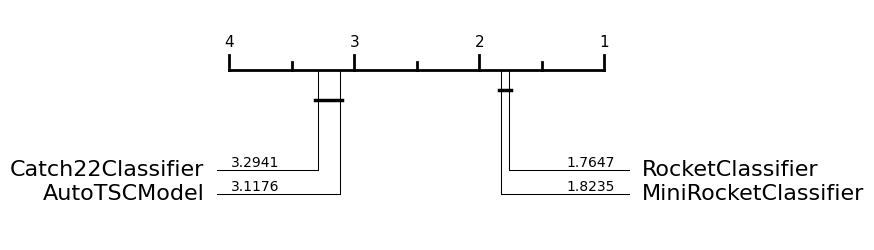

In [8]:
from aeon.visualisation import plot_critical_difference

plot_critical_difference(P, models)